# Tutorial 06: Complete Workflow — AT2019dsg

## Overview

Everything from the previous tutorials, on one object, end to end: optical and UV
photometry from ZTF and Swift/UVOT, X-ray photometry from Swift XRT, a disc plus an
early-time component, an MCMC fit, and the plots you would put in a paper.

Tutorial 04 fitted the X-rays plus one late-time UV band. Tutorial 05 turned that into a
posterior. This notebook adds the other four bands, turns the early-time model on, and
fits the whole thing.

## Learning Objectives

By the end of this tutorial, you will:

- See the whole workflow in one place
- Understand which data-preparation choices are safe and which introduce bias
- Know how to fit the early-time component alongside the disc
- Be able to produce posterior light curves, corner plots and Eddington-ratio plots
- Know how to judge whether the answer is trustworthy

## Prerequisites

- **Tutorials 01–05**
- **manyTDE**, for the optical and UV photometry:
  `git clone https://github.com/sjoertvv/manyTDE && cd manyTDE && pip install -e .`

If manyTDE is not installed the notebook stops after the setup cell with a clear message
rather than producing half a result.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# If FitTeD was installed with `pip install -e .` this block is unnecessary.
# It is here so the notebooks also work from a bare checkout.
package_dir = Path().resolve().parent
if str(package_dir) not in sys.path:
    sys.path.append(str(package_dir))   # append, so an installed copy wins

import fitted
fitted.format_plots()

print("FitTeD", fitted.__version__)


  _____  _  _   _____      ____   
 |  ___|(_)| |_|_   _|___ |  _ \  
 | |_   | || __| | | / _ \| | | | 
 |  _|  | || |_  | ||  __/| |_| | 
 |_|    |_| \__| |_| \___||____/  
                                  
   FITing TransiEnts with Discs   

 Version 2.0.0
 manyTDE compatible?  Yes

 FitTeD was created by Andrew Mummery* and Edward Nathan$.

 Please cite us if you make use of this code
 https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract

 * amummery@ias.edu
 $ edward.j.r.nathan@gmail.com




FitTeD 2.0.0


In [2]:
if fitted.data.manyTDE_available != "Yes":
    raise RuntimeError(
        "This tutorial needs manyTDE for the optical/UV photometry.\n"
        "  git clone https://github.com/sjoertvv/manyTDE\n"
        "  cd manyTDE && python3 -m pip install -e .\n"
        "Tutorials 04 and 05 fit data that ships with FitTeD and need no extra packages."
    )
print("manyTDE available")

manyTDE available


## Step 1: load the data

Two sources. Optical and UV come from manyTDE by IAU name; the X-rays come from the file
that ships with FitTeD, as observed fluxes that we convert to luminosities.

`global_systematic=0.1` adds 10% of the luminosity in quadrature to every uncertainty. For
a TDE this is not a fudge factor — it is a statement that a smooth disc model is not
expected to reproduce the data to the photometric precision of ZTF, because the model is
smooth and the source is not.

In [3]:
from astropy import units

BANDS = ['r.ztf', 'g.ztf', 'UVW1.uvot', 'UVW2.uvot', 'UVM2.uvot']
D_Mpc = 236.4

xray_file = package_dir / 'fitted' / 'examples' / '2019dsg_Xray.txt'
raw = np.genfromtxt(xray_file, skip_header=3)
kind = np.genfromtxt(xray_file, skip_header=3, usecols=(1), dtype=str)
scale = 4 * np.pi * (D_Mpc * units.Mpc.to(units.cm))**2
det, lim = kind == 'X', kind == 'XUL'

data_set = fitted.data.Data_Set(
    manyTDE_name='AT2019dsg',
    manyTDE_bands=BANDS,
    args_X=[[raw[:, 0][det], raw[:, 2][det] * scale,
             raw[:, 3][det] * scale, [0.3, 10]]],
    bands_X=['Swift XRT'],
    args_X_upperlim=[[raw[:, 0][lim], raw[:, 2][lim] * scale,
                      3 * np.ones(lim.sum()), [0.3, 10]]],
    bands_X_upperlim=['Swift XRT upper limit'],
    global_systematic=0.1,
)

print("redshift %.4f, luminosity distance %.1f Mpc"
      % (data_set.redshift, data_set.d_Mpc))
print("\n%-14s %7s   %-24s %s"
      % ("band", "points", "time range (rest-frame d)", "negative"))
raw_counts = {}
for band in data_set.bands_UV + data_set.bands_X:
    t, L, _ = data_set.args_band[band]
    raw_counts[band] = len(t)
    print("%-14s %7d   %6.0f to %6.0f          %d"
          % (band, len(t), t.min(), t.max(), (L < 0).sum()))

redshift 0.0512, luminosity distance 235.6 Mpc

band            points   time range (rest-frame d) negative
r.ztf              734     -375 to   2060          123
g.ztf              468     -375 to   2060          65
UVW1.uvot           36       16 to   1882          0
UVW2.uvot           39       16 to   1882          1
UVM2.uvot           37       16 to   1882          1
Swift XRT           10       16 to     43          0


## Step 2: prepare the data — and two traps

Two of the obvious data-cleaning moves are wrong, and both bias the result in the same
direction. They are worth stating explicitly because they are easy to do by accident.

### Trap 1: do not cut late-time data

It is tempting to drop data beyond a couple of years, on the grounds that host-galaxy
subtraction dominates the error budget there. **Do not.** Late-time emission is the most
disc-dominated data you have — it is exactly what Tutorial 04 exploited when it kept only
UVW1 beyond 150 days, and exactly what pins down the disc's size.

On this object a `t < 1000 d` cut would discard 33% of the r-band, 43% of the g-band, and
*every* UVOT point beyond 1000 days — all of which are clean detections.

### Trap 2: do not drop negative fluxes

Host-subtracted forced photometry is an **unbiased** measurement that scatters about the
true flux. Where the source has faded towards the host level, a fair fraction of
measurements come out negative — and if you are measuring nothing but host, you should get
negative about half the time.

Discard the negatives and you keep only the positive half of the scatter, which biases the
late-time flux upwards. The cell below measures that bias on this data set.

### What to do instead

**Rebin.** Inverse-variance weighted binning averages positive and negative measurements
together, which is unbiased, and it recovers a positive late-time value from data that
individually scatter through zero. It also fixes the cadence imbalance: ZTF has hundreds of
points in the first weeks and a handful per year later, so left alone the early data would
outvote the late data purely by weight of numbers.

In [4]:
# Measure the bias that dropping negatives would introduce, on the late r-band.
t_r, L_r, e_r = data_set.args_band['r.ztf']
late = t_r > 1000
w = 1.0 / e_r[late]**2
mean_all = np.sum(L_r[late] * w) / np.sum(w)
pos = L_r[late] > 0
w_pos = 1.0 / e_r[late][pos]**2
mean_pos = np.sum(L_r[late][pos] * w_pos) / np.sum(w_pos)

print("late r.ztf (t > 1000 d): %d points, %d of them negative"
      % (late.sum(), (~pos).sum()))
print("  inverse-variance mean, all points kept: %.3e erg/s" % mean_all)
print("  ... with negatives dropped:             %.3e erg/s" % mean_pos)
print("  => dropping them biases the late flux HIGH by %.0f%%"
      % (100 * (mean_pos / mean_all - 1)))

late r.ztf (t > 1000 d): 243 points, 75 of them negative
  inverse-variance mean, all points kept: 1.755e+41 erg/s
  ... with negatives dropped:             2.940e+41 erg/s
  => dropping them biases the late flux HIGH by 68%


In [5]:
# Rebin, progressively more coarsely with time. No time cut, no flux cut.
for band in BANDS:
    data_set.remove_before_time(band, t_start=-50)   # keep a little pre-flare baseline
    data_set.rebin_band(band, delta_t=10, t_end=100)              # dense early coverage
    data_set.rebin_band(band, delta_t=50, t_start=100, t_end=1000)
    data_set.rebin_band(band, delta_t=200, t_start=1000)          # sparse, precious late

print("%-14s %8s %8s   %s" % ("band", "before", "after", "time range after (d)"))
n_total = 0
for band in data_set.bands_UV + data_set.bands_X:
    t = data_set.args_band[band][0]
    n_total += len(t)
    print("%-14s %8d %8d   %6.0f to %6.0f"
          % (band, raw_counts[band], len(t), t.min(), t.max()))
print("\n%d data points in total" % n_total)

neg_bins = {b: int((data_set.args_band[b][1] < 0).sum()) for b in data_set.bands_UV}
neg_bins = {k: v for k, v in neg_bins.items() if v}
print("negative bins retained (kept deliberately): %s" % (neg_bins or "none"))

band             before    after   time range after (d)
r.ztf               734       31      -21 to   1945
g.ztf               468       27        9 to   1954
UVW1.uvot            36       17       22 to   1882
UVW2.uvot            39       16       22 to   1842
UVM2.uvot            37       16       22 to   1842
Swift XRT            10       10       16 to     43

117 data points in total
negative bins retained (kept deliberately): {'UVW2.uvot': 1}


Note the last line. After binning, almost every bin is positive — the negative individual
measurements have averaged with their positive neighbours into a sensible late-time
detection. Any bin that remains negative stays in the fit, where a Gaussian likelihood
handles it correctly.

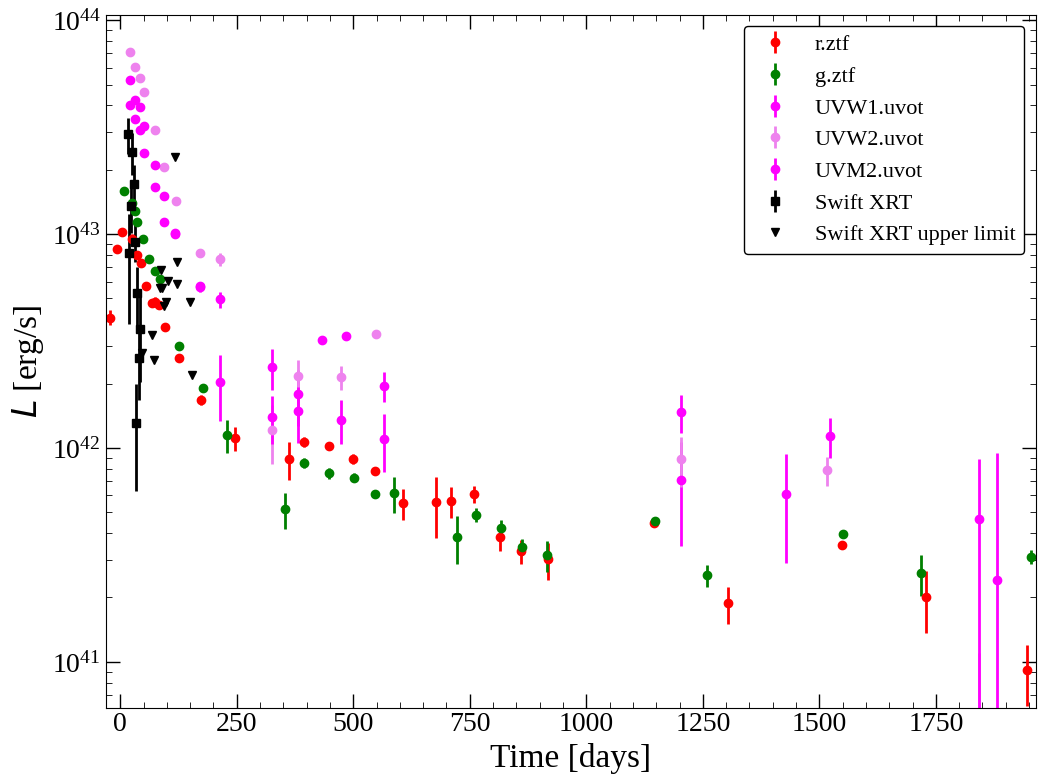

In [6]:
# plot_data defaults to log y and LINEAR x, which is what you want here: the
# late-time plateau is the disc, and a log time axis compresses it into the
# right-hand edge where you cannot see it.
fig = data_set.plot_data()
plt.show()

## Step 3: build the model

Now that we have optical, UV *and* X-ray data, the early-time component is constrained, so
we turn it on: a power-law decay with a Gaussian rise, the usual phenomenological
description of the optical flare. Thirteen parameters in total.

For the accuracy options we take the defaults, and here that matters more than usual.
Keeping the late-time data pushes the outer grid radius `r_out` to tens of thousands of
gravitational radii, which is precisely the regime where a fixed **linear** grid fails
badly (Tutorial 07). The cell after the fit checks this rather than assuming it.

In [7]:
model = fitted.models.GR_disc(
    data=data_set,
    decay=True,
    decay_type='pl',
    rise=True,
    # accuracy/speed options left at their defaults:
    #   radial_grid_spacing='geometric', default_N=1000,
    #   use_iv_approximation=True, use_dynamic_grid=False
)
fit = fitted.Fit(model=model)
names = list(model.default_key_pars + model.default_early_pars)
model.what_pars()


You are using the GR_disc model class.
This model samples 7 key parameters and 6 early-time parameters,
in this order:

  [ 0] log_mh      = the logarithm of the black hole mass in units of solar masses.
  [ 1] a_bh        = the black hole spin (dimensionless -0.999 < a_bh < 0.999).
  [ 2] log_m_disc  = log10 of the disc mass in solar masses.
  [ 3] log_r0      = log10 of the initial disc radius (gravitational radii).
  [ 4] log_tvi     = log10 of the viscous timescale in days.
  [ 5] t0          = time before first observation that the disc formed (days).
  [ 6] cos_incl    = the cosine of the disc-observer inclination angle.
  [ 7] log_L       = log10 of the peak luminosity of the non-disc component (erg/s at 6e14 Hz).
  [ 8] t_fb        = the fall-back timescale of the non-disc component (days).
  [ 9] p           = the power-law decay index of the non-disc component.
  [10] t_peak      = the time of peak of the non-disc component (days).
  [11] sigma       = the Gaussian rise time

## Step 4: a starting point

Two stages. First fit the early-time parameters alone, holding the disc fixed —
`get_early_model_pars` does this using only data before `t_cut`. Then optimise everything
together.

Doing the early component first matters: throw all thirteen parameters at the optimiser
from a cold start and the disc parameters tend to distort themselves trying to reproduce
the optical peak, which the disc cannot produce and is not meant to.

In [8]:
import time

start = model.pack_parameters(
    log_mh=6.7, a_bh=0.01, m_disc=0.05, r0=30.0, tvi=15.0, t0=-2.0, incl=70.0,
    log_L=43.3, t_fb=67.0, p=5/3, t_peak=1.0, sigma=8.0, log_T=4.4,
)

model.log_likelihood(start)                      # warm up the numba kernels
t = time.time()
for _ in range(10):
    fit.log_likelihood(start)
ms = (time.time() - t) / 10 * 1e3
print("%.1f ms per likelihood evaluation, %d data points" % (ms, n_total))
print("initial log L = %.1f" % fit.log_likelihood(start))

36.0 ms per likelihood evaluation, 117 data points
initial log L = -2301.9


In [9]:
t = time.time()
p0 = fit.best_fit(start, print_best_fit=True,
                  options={'maxiter': 30000, 'maxfev': 30000})
print(" optimisation took %.0f s" % (time.time() - t))
print(" log L improved from %.1f to %.1f"
      % (fit.log_likelihood(start), fit.log_likelihood(p0)))

 
 The fit was successful
 scipy message Optimization terminated successfully.
 The best fitting parameters are: 
 log_10 Black hole mass = 7.090  solar masses


 Black hole spin = -0.069


 Disc mass = 0.04781  solar masses


 Initial radius = 281.92  r_g


 Viscous timescale = 9.6  days


 Time offset = -10.8  days


 Inclination angle = 76.6  degrees


 
 The early time parameters are: 
 The early time luminosity is: 43.206  log_10(erg/s) at 6e14 Hz. 
 The fallback time is: 144.842  days. 
 The powerlaw index is: 4.560 . 
 The peak time is: 3.375  days. 
 The rise time is: 19.844  days. 
 The early time temperature is: 4.388  log_10(Kelvin). 
 
 optimisation took 224 s
 log L improved from -2301.9 to -222.9


In [10]:
# Does the grid choice matter at this baseline? Check, do not assume.
t_max = max(max(data_set.args_band[b][0]) for b in data_set.bands_UV)
print("longest baseline: %.0f days\n" % t_max)
print("%-12s %6s %18s" % ("spacing", "N", "log L at the best fit"))
for spacing, N in (('geometric', 1000), ('geometric', 3000), ('linear', 3000)):
    m = fitted.models.GR_disc(data=data_set, decay=True, decay_type='pl', rise=True,
                                 radial_grid_spacing=spacing, default_N=N,
                                 use_iv_approximation=False)
    print("%-12s %6d %18.4f" % (spacing, N, m.log_likelihood(p0)))

longest baseline: 1954 days

spacing           N log L at the best fit
geometric      1000          -222.8871


geometric      3000          -222.9049
linear         3000          -341.8741


The two geometric grids agree to a few hundredths of a log-likelihood unit. The linear grid
at the same `N` is wrong by **more than a hundred** — enough to move a best fit by many
sigma, and it would do so silently. This is the single most important accuracy setting in
the package for long-baseline TDE data, and it is why `radial_grid_spacing='geometric'` is
the default. Tutorial 07 has the details.

## Step 5: run the chain

Cost is `nwalkers × nsteps` evaluations, so use the timing above to choose. The settings
below are sized for a tutorial; see the table at the end for a publication run.

In [11]:
import os

NWALKERS, NSTEPS = 64, 1500
n_eval = NWALKERS * NSTEPS
print("%d walkers x %d steps = %d evaluations" % (NWALKERS, NSTEPS, n_eval))
print("~%.0f s of CPU time, across %d cores" % (n_eval * ms / 1e3, os.cpu_count()))

t = time.time()
fit.run_chain(
    full_pars=p0,
    nwalkers=NWALKERS,
    nsteps=NSTEPS,
    scatter=1e-3,
    backend_path='at2019dsg_tutorial.h5',
    overwrite_backend=True,
    progress=False,
    use_parallel=True,
)
wall = time.time() - t
print("\nchain finished in %.0f s (%.0f evaluations/s)" % (wall, n_eval / wall))
print("chain shape:", fit.chain.shape)

64 walkers x 1500 steps = 96000 evaluations
~3460 s of CPU time, across 2 cores
Existing at2019dsg_tutorial.h5 has been deleted



  _____  _  _   _____      ____   
 |  ___|(_)| |_|_   _|___ |  _ \  
 | |_   | || __| | | / _ \| | | | 
 |  _|  | || |_  | ||  __/| |_| | 
 |_|    |_| \__| |_| \___||____/  
                                  
   FITing TransiEnts with Discs   

 Version 2.0.0
 manyTDE compatible?  Yes

 FitTeD was created by Andrew Mummery* and Edward Nathan$.

 Please cite us if you make use of this code
 https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract

 * amummery@ias.edu
 $ edward.j.r.nathan@gmail.com



  _____  _  _   _____      ____   
 |  ___|(_)| |_|_   _|___ |  _ \  
 | |_   | || __| | | / _ \| | | | 
 |  _|  | || |_  | ||  __/| |_| | 
 |_|    |_| \__| |_| \___||____/  
                                  
   FITing TransiEnts with Discs   

 Version 2.0.0
 manyTDE compatible?  Yes

 FitTeD was created by Andrew Mummery* and Edward Nathan$.

 Please cite us if you make use of this code
 https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract

 * amummery@ias.edu
 $ edward


chain finished in 1431 s (67 evaluations/s)
chain shape: (1500, 64, 13)


## Step 6: check it before reading it

Thirteen parameters against a hundred-odd points, with real degeneracies. Check the
diagnostics before interpreting any number — Tutorial 05 explains what each one means.

In [12]:
f_discard = 0.5

acc = fit.sampler.acceptance_fraction
print("acceptance fraction: mean %.3f (healthy is roughly 0.2-0.5)" % acc.mean())

rhat = fit.compute_rhat(f_discard=f_discard)
print("\nR-hat after discarding %.0f%% (want < 1.01):" % (100 * f_discard))
for name, r in zip(names, rhat):
    print("  %-11s %6.3f%s" % (name, r, "" if r < 1.01 else "   <-- not converged"))
print("\nworst R-hat: %.3f" % rhat.max())
if rhat.max() > 1.01:
    print("Not converged. The numbers below show the machinery working; for a")
    print("publication run see the final section.")

acceptance fraction: mean 0.127 (healthy is roughly 0.2-0.5)

R-hat after discarding 50% (want < 1.01):
  log_mh       1.772   <-- not converged
  a_bh         1.508   <-- not converged
  log_m_disc   1.730   <-- not converged
  log_r0       2.204   <-- not converged
  log_tvi      2.059   <-- not converged
  t0           1.878   <-- not converged
  cos_incl     1.871   <-- not converged
  log_L        1.598   <-- not converged
  t_fb         1.510   <-- not converged
  p            1.457   <-- not converged
  t_peak       1.533   <-- not converged
  sigma        1.468   <-- not converged
  log_T        1.607   <-- not converged

worst R-hat: 2.204
Not converged. The numbers below show the machinery working; for a
publication run see the final section.


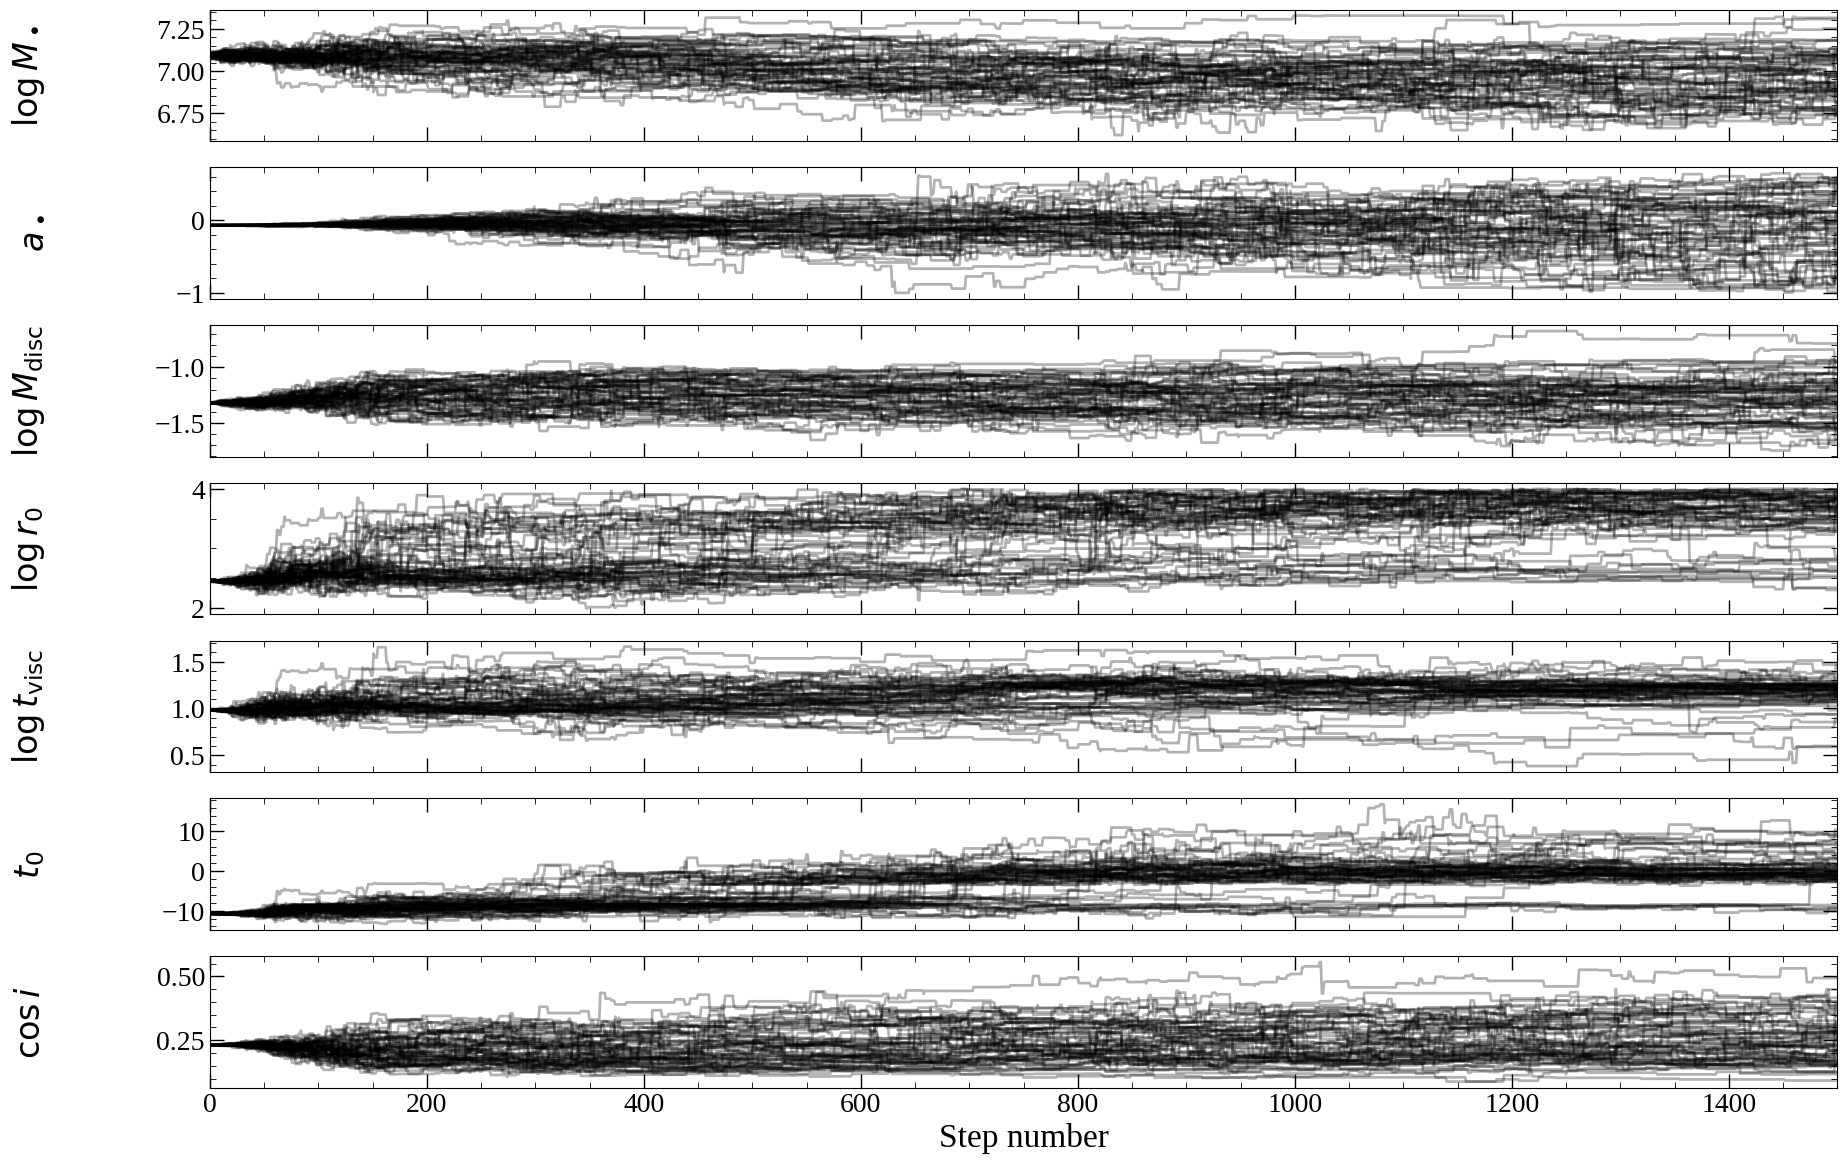

In [13]:
fig = fit.plot_walkers(just_disc=True)
plt.show()

## Step 7: results

Medians with 16th–84th percentiles, in physical units.

In [14]:
chain = fit.chain
flat = chain[int(f_discard * len(chain)):].reshape((-1, len(names)))
flat_phys = np.array([model.convert_parameters(s, names) for s in flat])

physical_names = (['log_mh', 'a_bh', 'm_disc', 'r0', 'tvi', 't0', 'incl']
                  + list(model.default_early_pars))
units_of = {'log_mh': 'log10 Msun', 'a_bh': '', 'm_disc': 'Msun', 'r0': 'r_g',
            'tvi': 'days', 't0': 'days', 'incl': 'deg', 'log_L': 'log10 erg/s',
            't_fb': 'days', 'p': '', 't_peak': 'days', 'sigma': 'days',
            'log_T': 'log10 K'}

q = np.percentile(flat_phys, [16, 50, 84], axis=0)
print("%d samples\n" % len(flat))
print("%-9s %12s %12s %12s   %s" % ("parameter", "median", "+", "-", "units"))
for i, name in enumerate(physical_names):
    print("%-9s %12.4g %12.3g %12.3g   %s"
          % (name, q[1, i], q[2, i] - q[1, i], q[1, i] - q[0, i],
             units_of.get(name, '')))

48000 samples

parameter       median            +            -   units
log_mh           6.966        0.123        0.139   log10 Msun
a_bh          -0.08447        0.326         0.37   
m_disc         0.05442       0.0254       0.0194   Msun
r0                3835     3.47e+03      3.3e+03   r_g
tvi              15.81         3.73          4.9   days
t0             -0.5163         3.03         2.49   days
incl              76.4         4.13         6.33   deg
log_L            43.12       0.0805       0.0696   log10 erg/s
t_fb             357.7         46.1         61.6   days
p                8.936        0.798         1.27   
t_peak          -5.987         5.27         4.87   days
sigma            15.66         7.89         6.02   days
log_T            4.551       0.0636       0.0793   log10 K


In [15]:
# How much is each parameter actually constrained? (Tutorial 05's diagnostic.)
qs = np.percentile(flat, [16, 84], axis=0)
print("posterior 16-84 width, as a percentage of the prior range:\n")
for i, name in enumerate(names):
    lo, hi = model.default_bounds[name]
    width = (hi - lo) if np.isfinite(hi) else (flat[:, i].max() - lo)
    print("  %-11s %4.0f%%" % (name, 100 * (qs[1, i] - qs[0, i]) / width))

posterior 16-84 width, as a percentage of the prior range:

  log_mh         3%
  a_bh          35%
  log_m_disc    15%
  log_r0        28%
  log_tvi        8%
  t0             1%
  cos_incl      18%
  log_L          0%
  t_fb          11%
  p             21%
  t_peak         5%
  sigma          1%
  log_T         14%


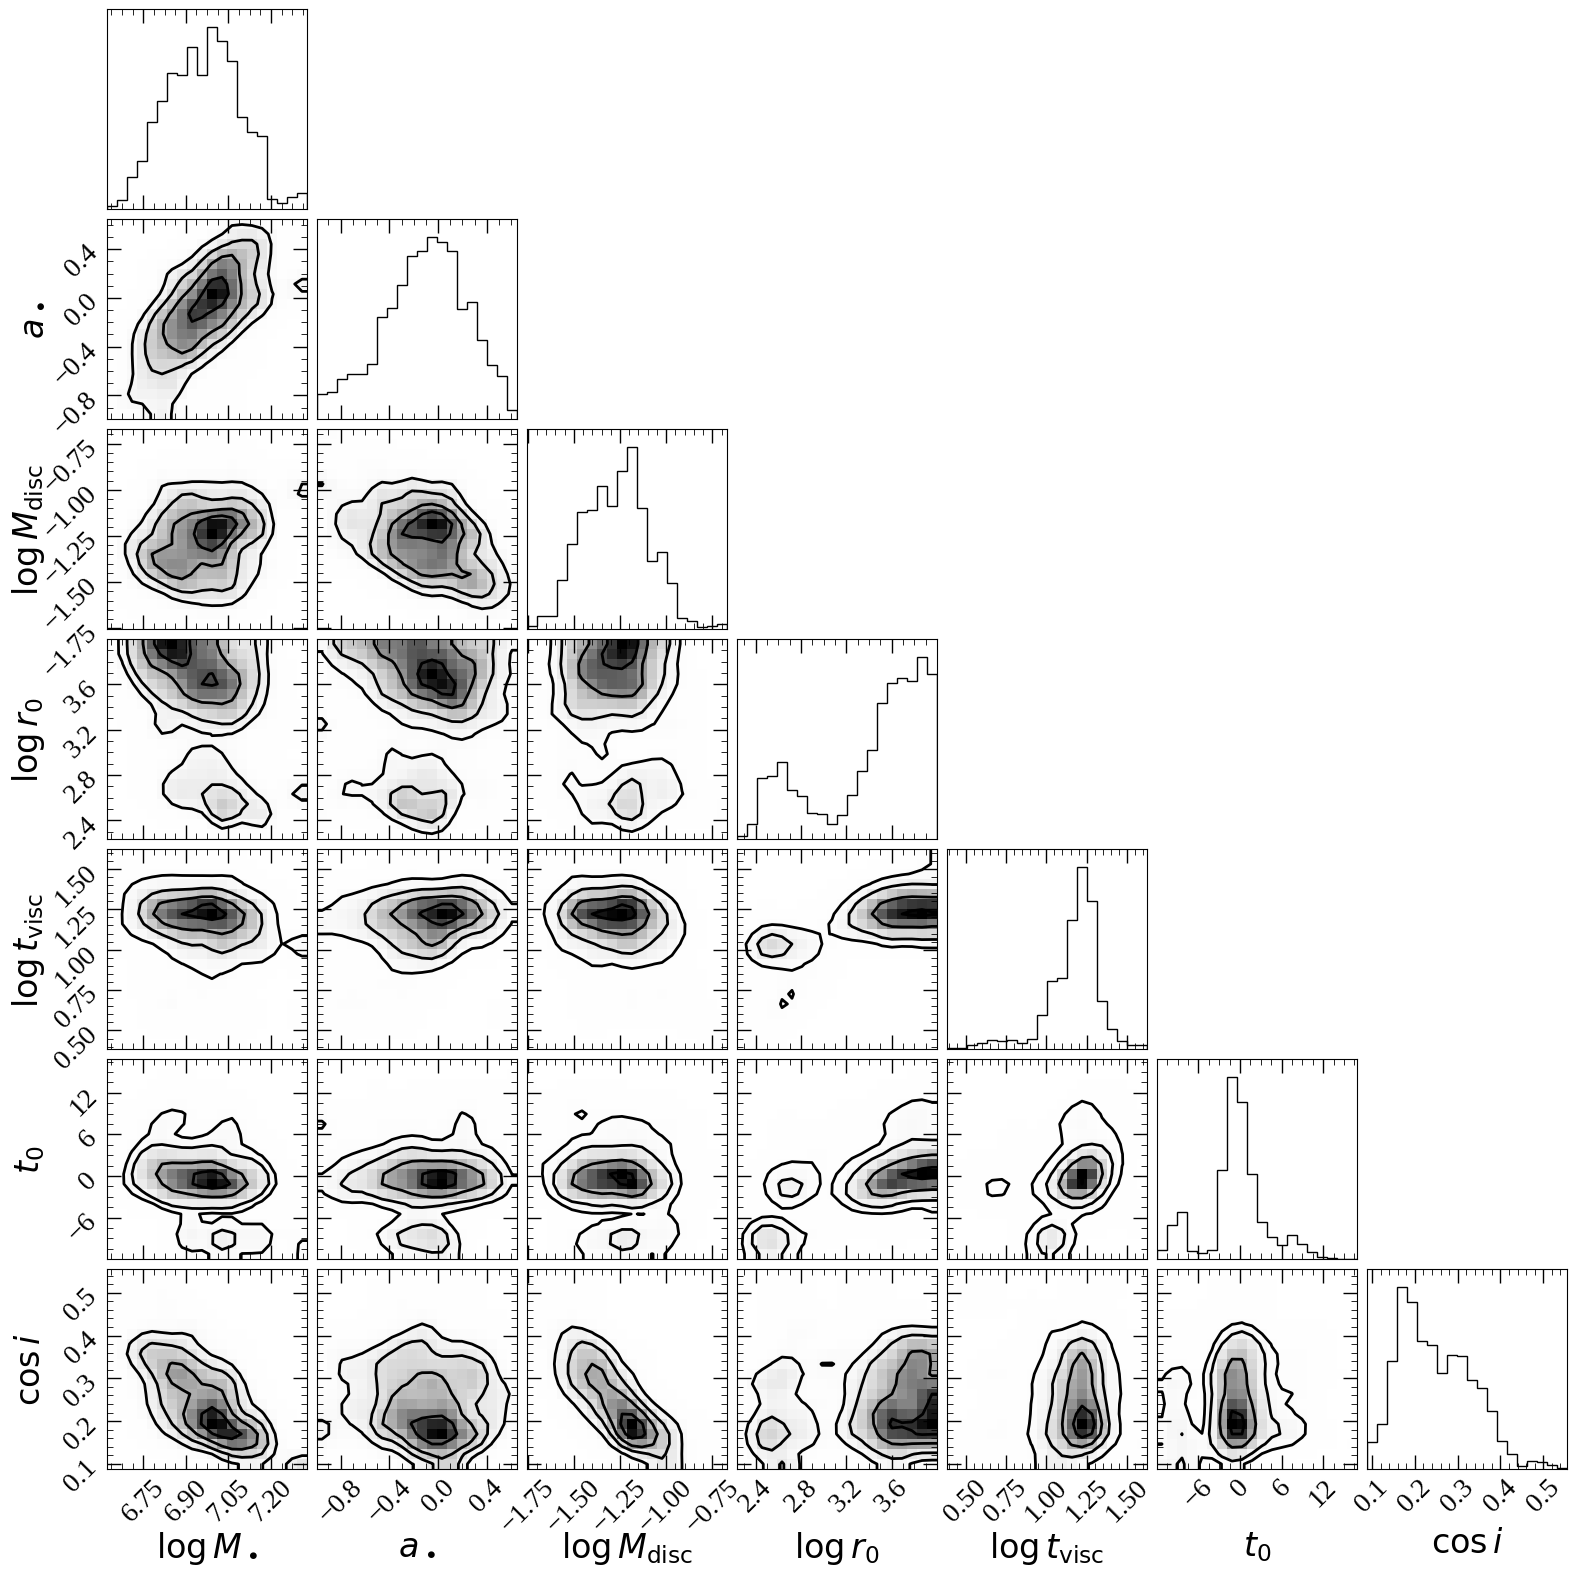

In [16]:
fig = fit.plot_corner(just_disc=True, f_discard=f_discard)
plt.show()

The corner plot is the honest summary. Look for the ridges — `log_mh` against `cos_incl`,
`log_m_disc` against `log_r0`. Those degeneracies are physical: a heavier hole seen more
edge-on produces a similar observed disc luminosity. They are what make a single best-fit
point misleading, and they are why the error bars are what they are.

## Step 8: posterior light curves

Rather than one best-fit curve, draw parameter sets from the posterior and plot the band
they span. This is the figure that shows whether the model actually describes the data.

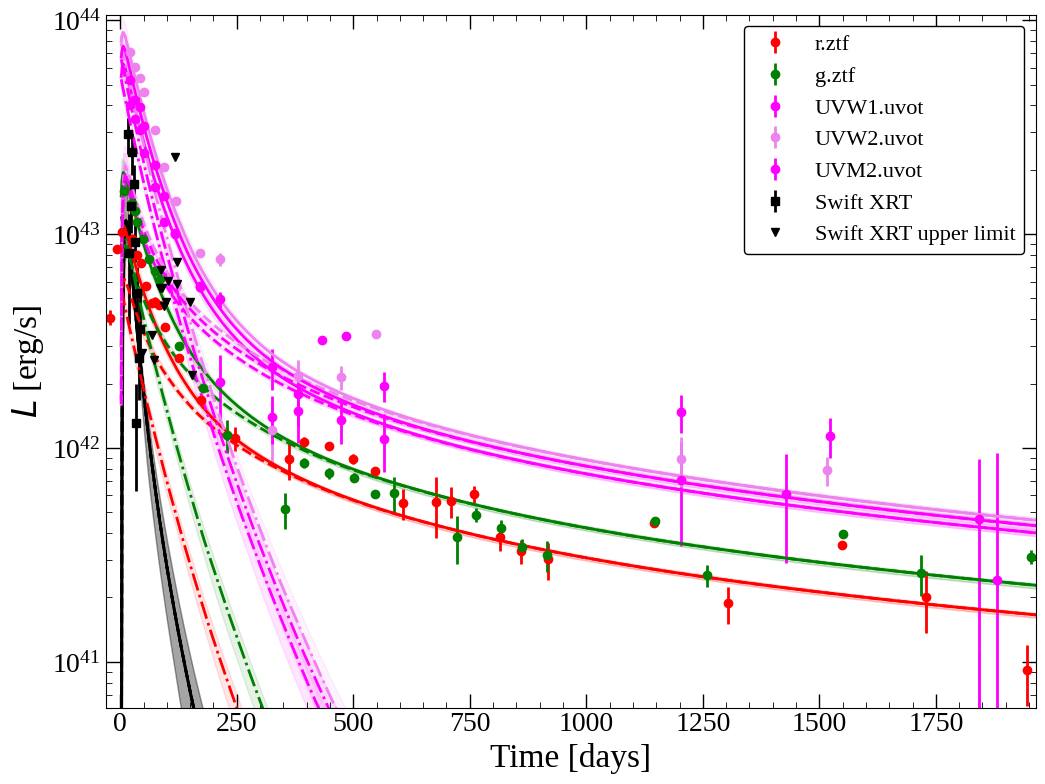

In [17]:
t_plot = np.logspace(np.log10(2), np.log10(2200), 250)

# Both plotting methods take a `fig`, so they compose: draw the data first, then
# overlay the posterior on the same axes. plot_data sets the scales and limits
# (log y, linear x) and plot_posterior_lightcurves leaves them alone.
fig = data_set.plot_data()
fig = fit.plot_posterior_lightcurves(
    t_plot,
    fig=fig,
    f_discard=f_discard,
    N=60,                 # posterior draws
    show_disc=True,
    show_early=True,      # the early-time component, separately
    show_total=True,
)
plt.show()

Three curves per band: the disc, the early-time component, and their sum. Read it as a
statement about which component the data assign the emission to at each epoch. The optical
peak belongs to the early component; the late optical and UV plateau and all of the X-rays
belong to the disc. That separation is the physical claim the fit is making, and it is worth
checking that it looks sensible before believing any parameter.

This is also where keeping the late data pays off: the late points are where the two
components are most cleanly separated, because only one of them is still emitting.

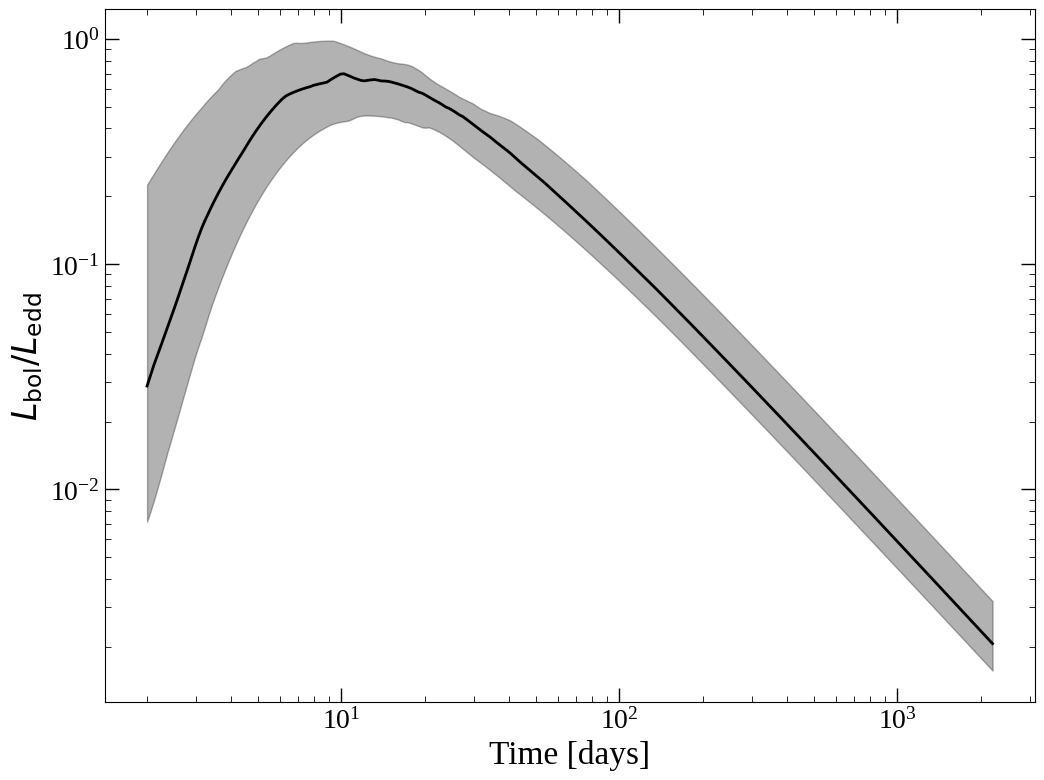

In [18]:
fig = fit.plot_bolometric_luminosity_posterior(
    t_plot, as_eddington=True, f_discard=f_discard, N=60,
)
plt.show()

The bolometric luminosity as a fraction of Eddington is a derived quantity — it depends on
the black hole mass, so its uncertainty inherits the mass uncertainty. It is the right plot
for asking whether the disc is in a state where the model's assumptions (thin, radiatively
efficient) hold.

## Step 9: save your work

```python
fit.save('at2019dsg')        # -> at2019dsg_FIT.pickle: model, data and chain together
```

The HDF5 backend written during `run_chain` holds the samples; the pickle holds everything
needed to regenerate the figures. Save both.

### Re-plotting without re-sampling

This chain took the best part of half an hour. You should never have to pay that again just
to change a figure — the samples are already on disk, so load them back into the `Fit` and
re-plot:

```python
import emcee

backend = emcee.backends.HDFBackend('at2019dsg_tutorial.h5', read_only=True)
fit.chain = backend.get_chain()          # (nsteps, nwalkers, ndim)

fig = data_set.plot_data()
fig = fit.plot_posterior_lightcurves(t_plot, fig=fig, f_discard=0.5, N=60)
```

Every plotting method reads `fit.chain`, so once it is populated they all work — corner
plots, walker traces, bolometric luminosity, the lot. The same trick lets you re-plot a
chain someone else ran, provided you rebuild the same model and data.

## What to change for a publication run

| Setting | Here | Publication |
|---------|------|-------------|
| `nsteps` | 1500 | run until R-hat < 1.01, typically several thousand |
| `nwalkers` | 64 | 100–200 |
| convergence | checked afterwards | `check_convergence=True, target_rhat=1.01` |
| `f_discard` | 0.5 | chosen by looking at the traces |
| bands | five optical/UV plus X-ray | as many as you trust |
| `global_systematic` | 0.1 | justify it, and check the result's sensitivity to it |

And three habits worth more than any of those:

- **Fit twice from different starting points.** If the posteriors disagree, the chain has
  not converged, whatever R-hat says.
- **Check sensitivity to the preparation.** Redo the fit with different bin widths, a
  different `t_start`, one band dropped. If the black hole mass moves by more than its
  quoted error, the quoted error is not the error.
- **Never cut data to make a fit behave.** If a subset of the data disagrees with the rest,
  that is a result, not a nuisance.

## Summary

- Load from manyTDE and from your own files in one `Data_Set`.
- **Keep late-time data** — it is the most disc-dominated you have.
- **Keep negative fluxes** — host-subtracted photometry is unbiased and scatters through
  zero; dropping them biases the late-time flux high, measurably.
- Rebin instead of cutting: it is unbiased, and it fixes cadence imbalance.
- Fit the early-time component first, then everything together.
- Check the grid at your baseline, check convergence, then read the numbers.
- Report posterior light curves, not a single best-fit curve.

## Next steps

- **Tutorial 07: Model Options Reference** — every accuracy and performance option, and
  when to change it

## Further reading

- **Paper Section 4**: the AT2019dsg analysis (arXiv:2408.15048)